# Radiative Heating and Precipitation Cross-Spectral Analysis

This notebook reproduces `Qr_Prec.ipynb` with the reusable, function-based workflow in `src/cross_spectrum_ana.py`. Data loading and every analysis stage remain visible so individual steps can be changed independently.

## 1. Imports

In [1]:
import sys
from datetime import datetime
from pathlib import Path

import netCDF4 as nc
import numpy as np
from matplotlib import pyplot as plt

sys.path.append("/home/b11209013/Manuscript_Prep/KW_CRI/src")
import cross_spectrum_ana as workflow

## 2. NetCDF helper functions

In [2]:
def convert_time(time_variable: nc.Variable) -> np.ndarray:
    """Return a NetCDF time coordinate as YYYY-MM-DD strings."""
    dates = nc.num2date(
        time_variable[:],
        units=time_variable.units,
        calendar=getattr(time_variable, "calendar", "standard"),
    )
    return np.asarray([date.strftime("%Y-%m-%d") for date in dates])


def as_float_array(values: np.ndarray) -> np.ndarray:
    """Convert a NetCDF array to float and replace masks with NaN."""
    masked_values = np.ma.asarray(values, dtype=np.float32)
    return np.asarray(masked_values.filled(np.nan))

## 3. Analysis configuration

Change these values when applying the same workflow to another period, latitude band, source, or reference variable.

In [3]:
DATA_PATH = Path("/data92/b11209013")
OUTPUT_PATH = Path("/home/b11209013/Manuscript_Prep/KW_CRI/Figure/Qr_Prec_workflow")

START_DATE = datetime(2006, 1, 1).strftime("%Y-%m-%d")
END_DATE = datetime(2018, 1, 1).strftime("%Y-%m-%d")
LATITUDE_BOUNDS = (-5.0, 5.0)

WINDOW_SIZE = 96
OVERLAP_SIZE = WINDOW_SIZE // 2
MERIDIONAL_COMPONENT = "symmetric"
SAMPLING_INTERVAL_DAYS = 1.0

REFERENCE_NAME = "Precipitation"
REFERENCE_KEY = "precipitation"
SOURCE_NAME = "SW"
COHERENCE_LEVELS = (0.5, 0.6, 0.8)

## 4. Load data

Data loading stays in the notebook because paths, variable names, dimensions, and time selection differ between datasets.

In [4]:
# Longwave radiative heating
with nc.Dataset(DATA_PATH / "CERES" / "column_LW_rm3harm.nc") as dataset:
    radiative_dates = convert_time(dataset.variables["time"])
    radiative_latitude = as_float_array(dataset.variables["lat"][:])
    radiative_longitude = as_float_array(dataset.variables["lon"][:])
    radiative_latitude_mask = (
        (radiative_latitude >= LATITUDE_BOUNDS[0])
        & (radiative_latitude <= LATITUDE_BOUNDS[1])
    )
    lw_heating = as_float_array(
        dataset.variables["column_LW"][:, radiative_latitude_mask, :]
    )

# Shortwave radiative heating
with nc.Dataset(DATA_PATH / "CERES" / "column_SW_rm3harm.nc") as dataset:
    shortwave_dates = convert_time(dataset.variables["time"])
    sw_heating = as_float_array(
        dataset.variables["column_SW"][:, radiative_latitude_mask, :]
    )

# Precipitation
with nc.Dataset(DATA_PATH / "IMERG" / "DATA" / "IMERG_1deg.nc") as dataset:
    all_precipitation_dates = convert_time(dataset.variables["time"])
    date_mask = (all_precipitation_dates >= START_DATE) & (
        all_precipitation_dates < END_DATE
    )
    precipitation_dates = all_precipitation_dates[date_mask]

    precipitation_latitude = as_float_array(dataset.variables["lat"][:])
    precipitation_longitude = as_float_array(dataset.variables["lon"][:])
    precipitation_latitude_mask = (
        (precipitation_latitude >= LATITUDE_BOUNDS[0])
        & (precipitation_latitude <= LATITUDE_BOUNDS[1])
    )
    precipitation = as_float_array(
        dataset.variables["precipitation"][
            date_mask, precipitation_latitude_mask, :
        ]
    )

qr_heating = lw_heating + sw_heating
source_fields = {
    "QR": qr_heating,
    "LW": lw_heating,
    "SW": sw_heating,
}
reference_field = precipitation

## 5. Remove the time-zonal mean

In [5]:
source_anomalies = {
    name: workflow.remove_time_zonal_mean(field)
    for name, field in source_fields.items()
}
reference_anomaly = workflow.remove_time_zonal_mean(reference_field)

## 6. Select the meridional component

Set `MERIDIONAL_COMPONENT` to `"symmetric"`, `"antisymmetric"`, or `"none"`.

In [6]:
source_components = {
    name: workflow.select_meridional_component(
        field, component=MERIDIONAL_COMPONENT
    )
    for name, field in source_anomalies.items()
}
reference_component = workflow.select_meridional_component(
    reference_anomaly,
    component=MERIDIONAL_COMPONENT,
)

## 7. Validate and segment the fields

The workflow validates array shapes and finite values. Coordinate equality must be checked from the loaded NetCDF coordinates when adapting this notebook to another dataset.

In [7]:
workflow.validate_aligned_fields(source_components, reference_component)

fields_for_segmentation = {
    **source_components,
    REFERENCE_KEY: reference_component,
}
chunked_fields = workflow.segment_fields(
    fields_for_segmentation,
    window_size=WINDOW_SIZE,
    overlap_size=OVERLAP_SIZE,
)

source_chunks = {
    name: chunked_fields[name]
    for name in source_components
}
reference_chunks = chunked_fields[REFERENCE_KEY]
n_segments, _, n_latitudes, n_longitudes = reference_chunks.shape
print(f"Windowed chunk shape: {reference_chunks.shape}")

Windowed chunk shape: (90, 96, 10, 360)


## 8. Calculate and average segment spectra

In [8]:
cross_spectrum, source_power_spectrum, reference_power_spectrum = (
    workflow.calculate_segment_spectra(
        source_chunks,
        reference_chunks,
        window_size=WINDOW_SIZE,
    )
)

(
    mean_cross_spectrum,
    mean_source_power_spectrum,
    mean_reference_power_spectrum,
) = workflow.average_segment_spectra(
    cross_spectrum,
    source_power_spectrum,
    reference_power_spectrum,
)

## 9. Calculate spectral diagnostics and coordinates

In [9]:
diagnostics = workflow.calculate_spectral_diagnostics(
    mean_cross_spectrum,
    mean_source_power_spectrum,
    mean_reference_power_spectrum,
)

cospectrum = diagnostics["cospectrum"]
quadrature_spectrum = diagnostics["quadrature_spectrum"]
normalized_cospectrum = diagnostics["normalized_cospectrum"]
coherence_squared = diagnostics["coherence_squared"]
phase_degrees = diagnostics["phase_degrees"]

frequencies, zonal_wavenumbers = workflow.spectral_coordinates(
    window_size=WINDOW_SIZE,
    n_longitudes=n_longitudes,
    sampling_interval=SAMPLING_INTERVAL_DAYS,
)

## 10. Prepare the selected spectrum for plotting

In [10]:
(
    shifted_wavenumbers,
    frequency_display,
    cospectrum_display,
    coherence_display,
) = workflow.prepare_plot_data(
    frequencies,
    zonal_wavenumbers,
    normalized_cospectrum[SOURCE_NAME],
    coherence_squared[SOURCE_NAME],
)

## 11. Generate and save the figure

Figure saving remains explicit in the notebook. Change the plot-function arguments here to customize the presentation.

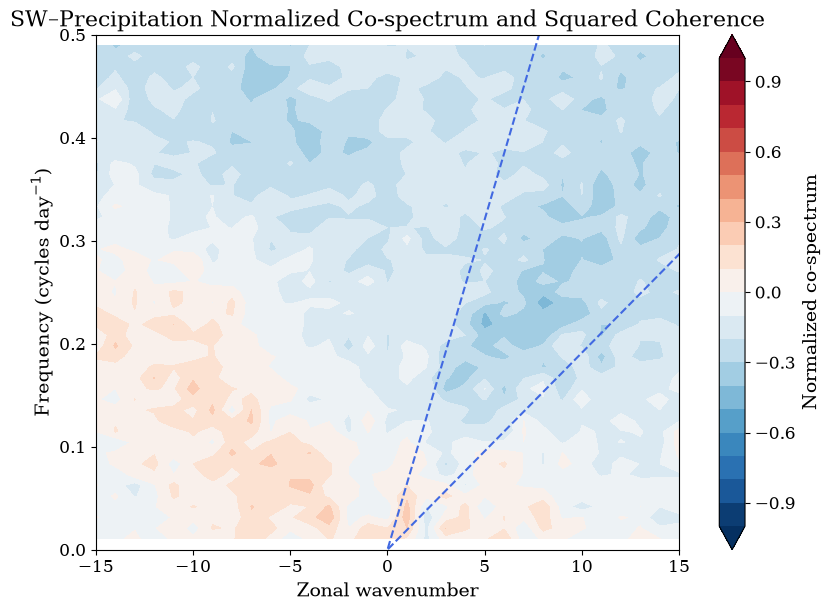

In [11]:
plt.rcParams.update(
    {
        "font.family": "serif",
        "font.size": 14,
        "axes.labelsize": 14,
        "axes.titlesize": 16,
        "xtick.labelsize": 12,
        "ytick.labelsize": 12,
        "legend.fontsize": 12,
        "figure.titlesize": 18,
    }
)

figure, axis = workflow.plot_cospectrum_with_coherence(
    shifted_wavenumbers,
    frequency_display,
    cospectrum_display,
    coherence_display,
    source_name=SOURCE_NAME,
    reference_name=REFERENCE_NAME,
    shading_levels=np.linspace(-1.0, 1.0, 21),
    coherence_levels=COHERENCE_LEVELS,
    equivalent_depths=(8.0, 90.0),
    cmap="RdBu_r",
    colorbar_label="Normalized co-spectrum",
    x_limits=(-15.0, 15.0),
    y_limits=(0.0, 0.5),
)
axis.set_title(
    f"{SOURCE_NAME}–{REFERENCE_NAME} Normalized Co-spectrum and Squared Coherence"
)

OUTPUT_PATH.mkdir(parents=True, exist_ok=True)
figure.savefig(
    OUTPUT_PATH / f"{SOURCE_NAME}.png",
    dpi=600,
    bbox_inches="tight",
)
plt.show()